# E - Explore: Eksplorasi Data Analitik IDM 2024
## Kelompok 3 - II4013 Data Analytics

Notebook ini murni melakukan analisis eksploratif data (EDA) pada dataset bersih `idm_2024_modeling.csv` hasil dari tahap Scrub.

### Alur Eksplorasi:
1. **Descriptive Statistics**: Analisis ringkasan statistik variabel numerik utama.
2. **Analisis Wilayah Tertinggal (RQ1)**: Mengidentifikasi provinsi dan kabupaten dengan tingkat ketertinggalan paling tinggi.
3. **Proporsi & Segmentasi Status Desa (RQ2)**: Menganalisis sebaran status desa secara nasional.
4. **Analisis Dimensi Penghambat (RQ3)**: Menganalisis gap dimensi indeks untuk menentukan dimensi penentu ketertinggalan.
5. **Identifikasi Potensi Desa (RQ4)**: Pemetaan desa-desa yang berpotensi besar naik kelas ke tingkat berikutnya.
6. **Visualisasi Korelasi & Hubungan**: Heatmap korelasi dan visualisasi hubungan antar-indeks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan grafik
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_theme(style='whitegrid', palette='muted')

print('[OK] Library dan konfigurasi grafik siap.')

[OK] Library dan konfigurasi grafik siap.


In [2]:
BASE_DIR = os.path.dirname(os.getcwd())
PROCESSED_DATA_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'idm_2024_modeling.csv')

df = pd.read_csv(PROCESSED_DATA_PATH, dtype={'KODE_DESA': str, 'KODE_PROV': str, 'KODE_KAB': str, 'KODE_KEC': str})
print(f'Memuat dataset modeling: {df.shape[0]:,} baris x {df.shape[1]} kolom')
df.head(3)

Memuat dataset modeling: 75,261 baris x 26 kolom


,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,IKS_2024,IKE_2024,IKL_2024,NILAI_IDM_2024,STATUS_IDM_2024,jumlah_rekomendasi,total_nilai_rekomendasi,keterangan_gabungan,target_idm_2025,has_rekomendasi,dimensi_terendah,gap_iks_ike,gap_iks_ikl,intensitas_rekomendasi,is_outlier_iks,is_outlier_ike,is_outlier_ikl,is_outlier_nilai
0,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012001,KEUDE BAKONGAN,0.8000,0.9000,0.5333,0.7444,MAJU,0,0.0000,Tidak ada data rekomendasi,MAJU,False,Lingkungan,-0.1000,0.2667,0.0000,False,False,False,False
1,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012002,UJONG MANGKI,0.6629,0.6333,0.5333,0.6098,BERKEMBANG,0,0.0000,Tidak ada data rekomendasi,BERKEMBANG,False,Lingkungan,0.0296,0.1296,0.0000,False,False,False,False
2,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012003,UJONG PADANG,0.7029,0.6167,0.5333,0.6176,BERKEMBANG,0,0.0000,Tidak ada data rekomendasi,BERKEMBANG,False,Lingkungan,0.0862,0.1696,0.0000,False,False,False,False


In [3]:
print('--- Statistik Deskriptif Variabel Utama ---')
fitur_numerik = ['IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024', 'jumlah_rekomendasi', 'gap_iks_ike', 'gap_iks_ikl']
display(df[fitur_numerik].describe())

print('\n--- Distribusi Kolom Kategorikal ---')
print(df['STATUS_IDM_2024'].value_counts())
print('\nModus status desa:', df['STATUS_IDM_2024'].mode()[0])

--- Statistik Deskriptif Variabel Utama ---


,IKS_2024,IKE_2024,IKL_2024,NILAI_IDM_2024,jumlah_rekomendasi,gap_iks_ike,gap_iks_ikl
count,75261.0000,75261.0000,75261.0000,75261.0000,75261.0000,75261.0000,75261.0000
mean,0.7662,0.6198,0.7502,0.7120,11.2668,0.1464,0.0159
std,0.1215,0.1736,0.1462,0.1208,11.7305,0.1105,0.1492
min,0.2057,0.1139,0.0000,0.2176,0.0000,-0.3619,-0.6971
25%,0.7143,0.5167,0.6667,0.6448,0.0000,0.0704,-0.0896
50%,0.7886,0.6333,0.6667,0.7156,11.0000,0.1467,0.0153
75%,0.8457,0.7333,0.8667,0.8075,21.0000,0.2196,0.1219
max,1.0000,1.0000,1.0000,1.0000,94.0000,0.6419,0.8000



--- Distribusi Kolom Kategorikal ---
STATUS_IDM_2024
BERKEMBANG           24532
MAJU                 23063
MANDIRI              17203
TERTINGGAL            6100
SANGAT TERTINGGAL     4363
Name: count, dtype: int64

Modus status desa: BERKEMBANG


### 1. Wilayah dengan Ketertinggalan Paling Tinggi (RQ1 & Obj1)
Kita mengukur ketertinggalan suatu provinsi dengan menghitung persentase desa berstatus **Tertinggal** dan **Sangat Tertinggal** terhadap total desa di provinsi tersebut.

--- Top 10 Provinsi dengan Persentase Ketertinggalan Tertinggi ---


,NAMA_PROVINSI,total_desa,desa_tertinggal,persentase_tertinggal
25,PAPUA PEGUNUNGAN,2617,2599,99.3100
27,PAPUA TENGAH,1172,1103,94.1100
24,PAPUA BARAT DAYA,939,799,85.0900
26,PAPUA SELATAN,677,526,77.7000
23,PAPUA BARAT,803,587,73.1000
22,PAPUA,948,509,53.6900
19,MALUKU UTARA,1067,446,41.8000
21,NUSA TENGGARA TIMUR,3137,1033,32.9300
36,SUMATERA UTARA,5417,1325,24.4600
29,SULAWESI BARAT,575,112,19.4800


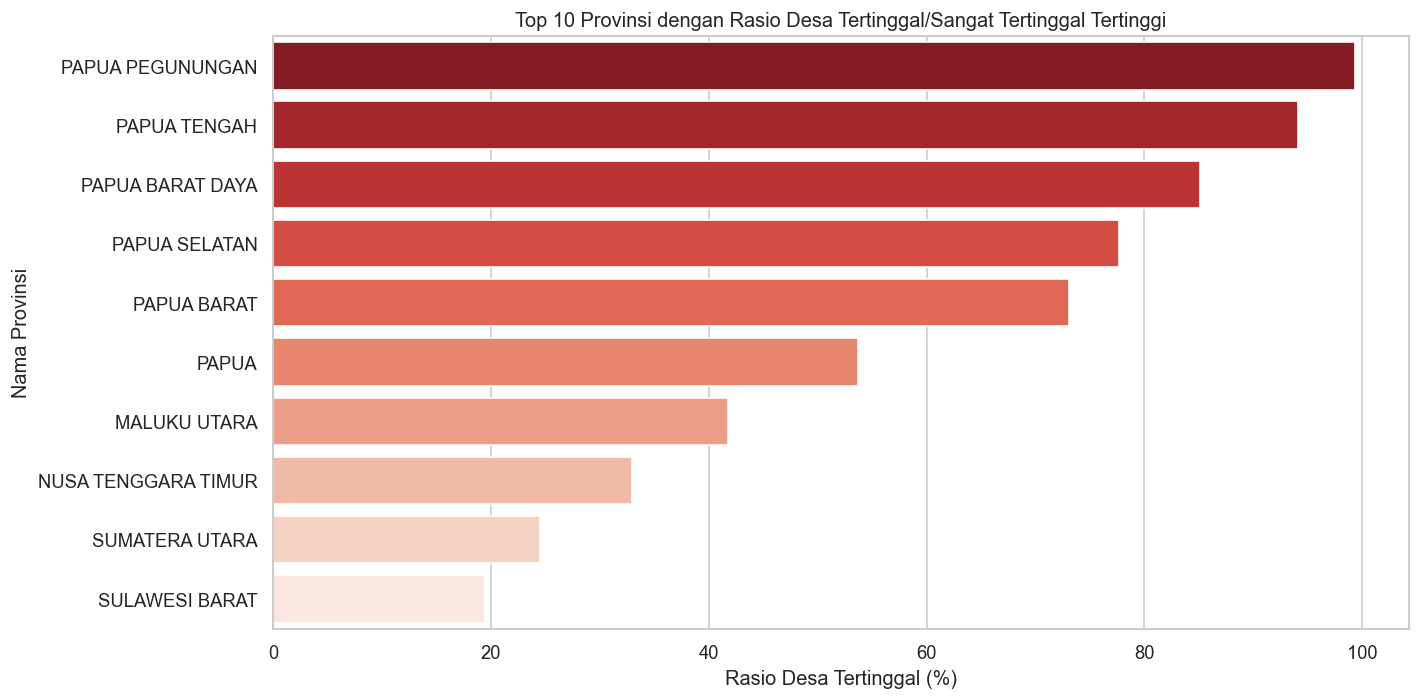

In [4]:
# Menghitung persentase desa tertinggal/sangat tertinggal per provinsi
df['is_tertinggal'] = df['STATUS_IDM_2024'].isin(['TERTINGGAL', 'SANGAT TERTINGGAL'])

prov_tertinggal = df.groupby('NAMA_PROVINSI').agg(
    total_desa=('KODE_DESA', 'count'),
    desa_tertinggal=('is_tertinggal', 'sum')
).reset_index()
prov_tertinggal['persentase_tertinggal'] = (prov_tertinggal['desa_tertinggal'] / prov_tertinggal['total_desa'] * 100).round(2)
prov_tertinggal = prov_tertinggal.sort_values('persentase_tertinggal', ascending=False)

print('--- Top 10 Provinsi dengan Persentase Ketertinggalan Tertinggi ---')
display(prov_tertinggal.head(10))

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=prov_tertinggal.head(10), x='persentase_tertinggal', y='NAMA_PROVINSI', palette='Reds_r')
plt.title('Top 10 Provinsi dengan Rasio Desa Tertinggal/Sangat Tertinggal Tertinggi')
plt.xlabel('Rasio Desa Tertinggal (%)')
plt.ylabel('Nama Provinsi')
plt.tight_layout()
plt.show()

### 2. Proporsi dan Segmentasi Desa secara Nasional (RQ2 & Obj2)
Kita menganalisis proporsi desa berdasarkan lima kategori status IDM 2024 secara nasional.

--- Sebaran Proporsi Status Desa Nasional 2024 ---


,STATUS_IDM_2024,JUMLAH,PERSENTASE
0,BERKEMBANG,24532,32.6000
1,MAJU,23063,30.6400
2,MANDIRI,17203,22.8600
3,TERTINGGAL,6100,8.1100
4,SANGAT TERTINGGAL,4363,5.8000


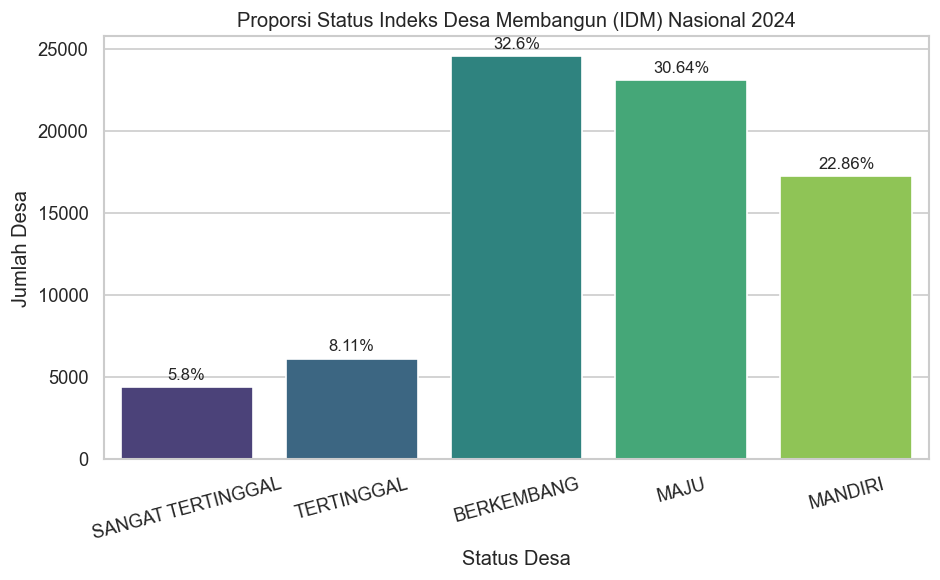

In [5]:
status_counts = df['STATUS_IDM_2024'].value_counts().reset_index()
status_counts.columns = ['STATUS_IDM_2024', 'JUMLAH']
status_counts['PERSENTASE'] = (status_counts['JUMLAH'] / len(df) * 100).round(2)

print('--- Sebaran Proporsi Status Desa Nasional 2024 ---')
display(status_counts)

# Plotting
plt.figure(figsize=(8, 5))
order = ['SANGAT TERTINGGAL', 'TERTINGGAL', 'BERKEMBANG', 'MAJU', 'MANDIRI']
sns.barplot(data=status_counts, x='STATUS_IDM_2024', y='JUMLAH', order=order, palette='viridis')
plt.title('Proporsi Status Indeks Desa Membangun (IDM) Nasional 2024')
plt.xlabel('Status Desa')
plt.ylabel('Jumlah Desa')
plt.xticks(rotation=15)
for idx, row in status_counts.iterrows():
    # Get index in the ordered list
    if row['STATUS_IDM_2024'] in order:
        pos = order.index(row['STATUS_IDM_2024'])
        plt.text(pos, row['JUMLAH'] + 500, f"{row['PERSENTASE']}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 3. Dimensi Indeks IDM Penghambat Terbesar (RQ3 & Obj3)
Kita menganalisis dimensi terendah pada tingkat nasional dan desa-desa tertinggal untuk mengetahui pilar pembangunan mana yang paling sering menghambat kemajuan desa.

--- Distribusi Dimensi Terendah Nasional ---


,DIMENSI,JUMLAH,PERSENTASE
0,Ekonomi,56054,74.4800
1,Lingkungan,15576,20.7000
2,Sosial,3631,4.8200



--- Distribusi Dimensi Terendah pada Desa Tertinggal & Sangat Tertinggal ---


,DIMENSI,JUMLAH,PERSENTASE
0,Ekonomi,9818,93.8400
1,Lingkungan,540,5.1600
2,Sosial,105,1.0000


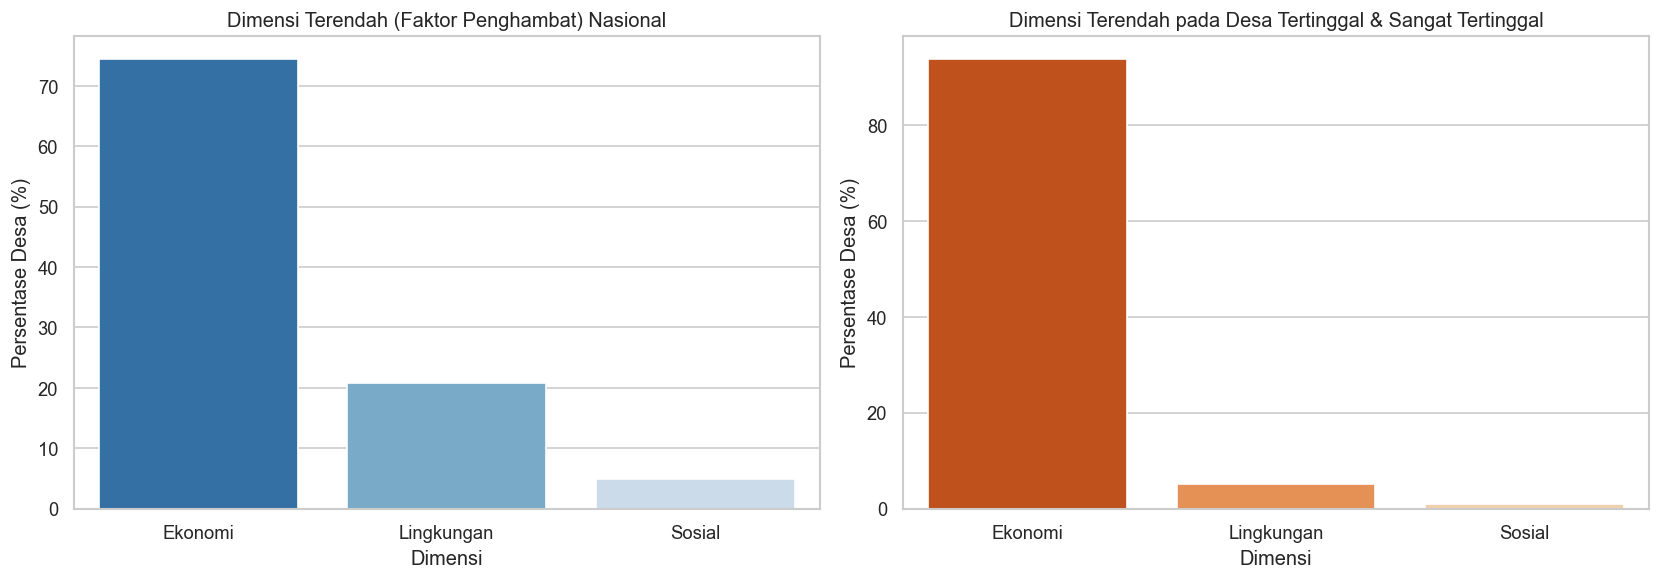

In [6]:
print('--- Distribusi Dimensi Terendah Nasional ---')
dimensi_terendah_counts = df['dimensi_terendah'].value_counts().reset_index()
dimensi_terendah_counts.columns = ['DIMENSI', 'JUMLAH']
dimensi_terendah_counts['PERSENTASE'] = (dimensi_terendah_counts['JUMLAH'] / len(df) * 100).round(2)
display(dimensi_terendah_counts)

print('\n--- Distribusi Dimensi Terendah pada Desa Tertinggal & Sangat Tertinggal ---')
df_tertinggal_only = df[df['STATUS_IDM_2024'].isin(['TERTINGGAL', 'SANGAT TERTINGGAL'])]
dim_tertinggal_counts = df_tertinggal_only['dimensi_terendah'].value_counts().reset_index()
dim_tertinggal_counts.columns = ['DIMENSI', 'JUMLAH']
dim_tertinggal_counts['PERSENTASE'] = (dim_tertinggal_counts['JUMLAH'] / len(df_tertinggal_only) * 100).round(2)
display(dim_tertinggal_counts)

# Plotting perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=dimensi_terendah_counts, x='DIMENSI', y='PERSENTASE', ax=axes[0], palette='Blues_r')
axes[0].set_title('Dimensi Terendah (Faktor Penghambat) Nasional')
axes[0].set_ylabel('Persentase Desa (%)')
axes[0].set_xlabel('Dimensi')

sns.barplot(data=dim_tertinggal_counts, x='DIMENSI', y='PERSENTASE', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Dimensi Terendah pada Desa Tertinggal & Sangat Tertinggal')
axes[1].set_ylabel('Persentase Desa (%)')
axes[1].set_xlabel('Dimensi')

plt.tight_layout()
plt.show()

### 4. Desa dengan Potensi Berkembang Terbesar (RQ4 & Obj4)
Desa dengan potensi berkembang tertinggi adalah desa yang skor IDM-nya berada sangat dekat di bawah batas kelas berikutnya, serta memiliki kesenjangan ekonomi/sosial yang relatif kecil sehingga sedikit intervensi terarah dapat membuat desa tersebut naik kelas.

In [7]:
# Menentukan batas skor IDM (Sangat Tertinggal < 0.4907 <= Tertinggal < 0.5989 <= Berkembang < 0.7072 <= Maju < 0.8155 <= Mandiri)
# Desa berpotensi berkembang ke kelas berikutnya adalah yang nilainya berada di batas 0.02 di bawah ambang batas status di atasnya.
def check_potensi(row):
    nilai = row['NILAI_IDM_2024']
    status = row['STATUS_IDM_2024']
    if status == 'SANGAT TERTINGGAL' and 0.4707 <= nilai < 0.4907:
        return 'Potensi ke TERTINGGAL'
    elif status == 'TERTINGGAL' and 0.5789 <= nilai < 0.5989:
        return 'Potensi ke BERKEMBANG'
    elif status == 'BERKEMBANG' and 0.6872 <= nilai < 0.7072:
        return 'Potensi ke MAJU'
    elif status == 'MAJU' and 0.7955 <= nilai < 0.8155:
        return 'Potensi ke MANDIRI'
    return 'Biasa'

df['potensi_naik'] = df.apply(check_potensi, axis=1)
potensi_counts = df['potensi_naik'].value_counts().reset_index()
potensi_counts.columns = ['KATEGORI_POTENSI', 'JUMLAH']
display(potensi_counts)

# Contoh desa berkembang dengan potensi besar ke kelas berikutnya
print('\n--- Contoh Desa Berkembang dengan Potensi Naik Kelas Paling Dekat (ke MAJU) ---')
df_potensi_maju = df[df['potensi_naik'] == 'Potensi ke MAJU'].sort_values('NILAI_IDM_2024', ascending=False)
display(df_potensi_maju[['NAMA_PROVINSI', 'NAMA_KABUPATEN', 'NAMA_KECAMATAN', 'NAMA_DESA', 'NILAI_IDM_2024', 'dimensi_terendah', 'jumlah_rekomendasi']].head(5))

,KATEGORI_POTENSI,JUMLAH
0,Biasa,63048
1,Potensi ke MAJU,6259
2,Potensi ke MANDIRI,3661
3,Potensi ke BERKEMBANG,1248
4,Potensi ke TERTINGGAL,1045



--- Contoh Desa Berkembang dengan Potensi Naik Kelas Paling Dekat (ke MAJU) ---


,NAMA_PROVINSI,NAMA_KABUPATEN,NAMA_KECAMATAN,NAMA_DESA,NILAI_IDM_2024,dimensi_terendah,jumlah_rekomendasi
7368,SUMATERA UTARA,LANGKAT,WAMPU,BESILAM BUKIT LEMBASA,0.7071,Lingkungan,0
25116,JAWA BARAT,TASIKMALAYA,CULAMEGA,MEKARLAKSANA,0.7071,Lingkungan,23
13683,RIAU,INDRAGIRI HILIR,CONCONG,PANGLIMA RAJA,0.7071,Ekonomi,24
5804,ACEH,BENER MERIAH,BANDAR,TANJUNG PURA,0.7071,Lingkungan,0
64801,GORONTALO,BOALEMO,PAGUYAMAN,SARIPI,0.7071,Lingkungan,20


### 5. Hubungan Antar-Indeks Komposit dan Korelasi Rekomendasi (RQ5 & Obj5)
Kita menganalisis korelasi antar-fitur indeks numerik untuk memahami hubungan ketahanan desa dan bagaimana rekomendasi berkorelasi dengan kondisi desa.

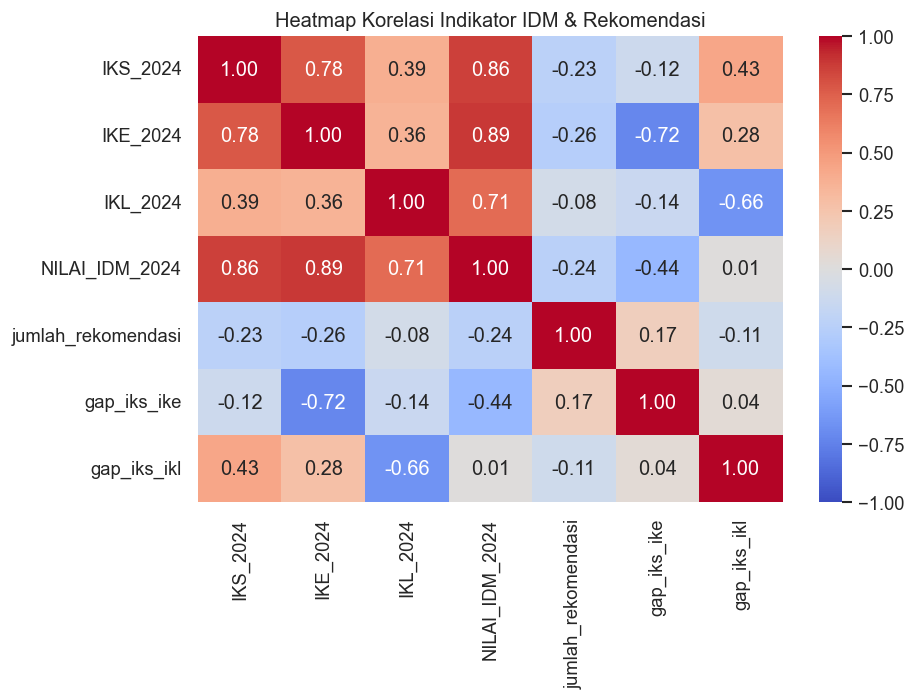

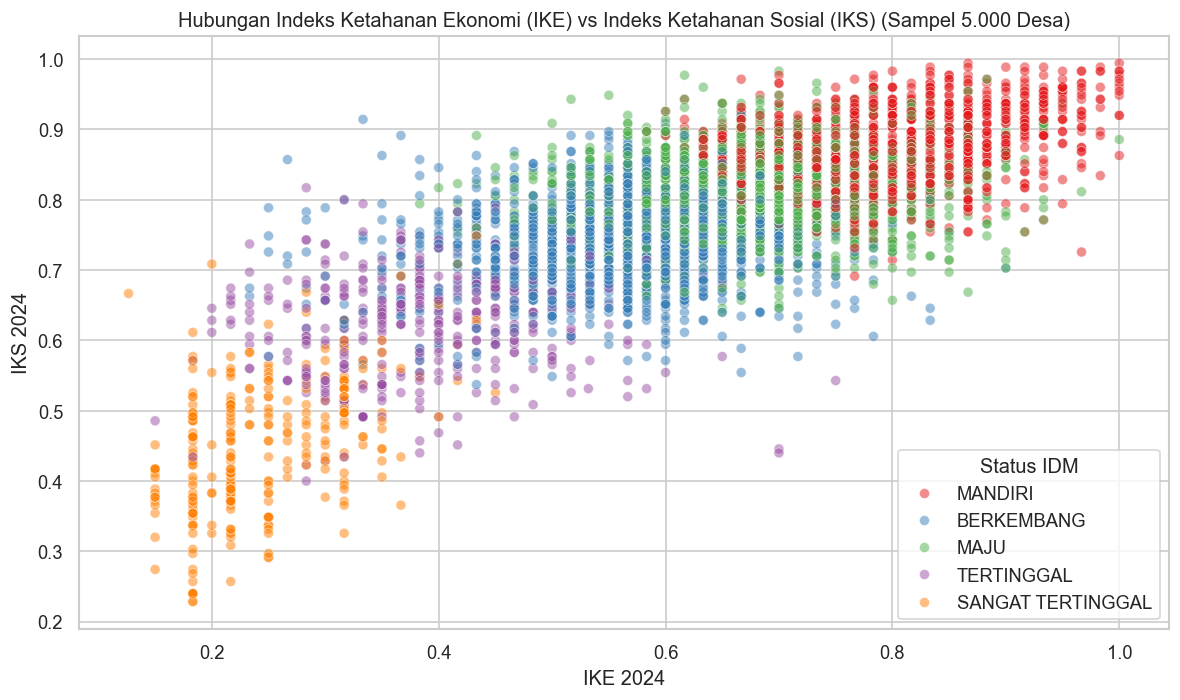

In [8]:
# Korelasi heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[['IKS_2024', 'IKE_2024', 'IKL_2024', 'NILAI_IDM_2024', 'jumlah_rekomendasi', 'gap_iks_ike', 'gap_iks_ikl']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Indikator IDM & Rekomendasi')
plt.tight_layout()
plt.show()

# Scatter plot hubungan IKE dan IKS berdasarkan Status Desa
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), x='IKE_2024', y='IKS_2024', hue='STATUS_IDM_2024', alpha=0.5, palette='Set1')
plt.title('Hubungan Indeks Ketahanan Ekonomi (IKE) vs Indeks Ketahanan Sosial (IKS) (Sampel 5.000 Desa)')
plt.xlabel('IKE 2024')
plt.ylabel('IKS 2024')
plt.legend(title='Status IDM')
plt.tight_layout()
plt.show()

### 6. Ringkasan Statistik Indeks dan Modus Status per Provinsi
Bagian ini mengekstrak profil pembangunan tingkat daerah untuk melihat nilai median indikator dan modus status desa di setiap provinsi.

In [9]:
# Median numerik dan Modus status per provinsi
def get_mode(series):
    return series.mode()[0] if not series.dropna().empty else np.nan

prov_stats = df.groupby('NAMA_PROVINSI').agg(
    IKS_median=('IKS_2024', 'median'),
    IKE_median=('IKE_2024', 'median'),
    IKL_median=('IKL_2024', 'median'),
    NILAI_IDM_median=('NILAI_IDM_2024', 'median'),
    STATUS_IDM_modus=('STATUS_IDM_2024', get_mode),
    jumlah_desa=('KODE_DESA', 'count')
).reset_index()

print('--- Ringkasan Statistik Provinsi (Diurutkan berdasarkan Median Nilai IDM Terendah) ---')
display(prov_stats.sort_values('NILAI_IDM_median', ascending=True))

# Simpan statistik wilayah untuk keperluan visualisasi dashboard
prov_stats_path = os.path.join(BASE_DIR, 'data', 'processed', 'provinsi_stats_summary.csv')
prov_stats.to_csv(prov_stats_path, index=False)
print(f'\n[SUCCESS] Ringkasan statistik provinsi disimpan ke: {prov_stats_path}')

--- Ringkasan Statistik Provinsi (Diurutkan berdasarkan Median Nilai IDM Terendah) ---


,NAMA_PROVINSI,IKS_median,IKE_median,IKL_median,NILAI_IDM_median,STATUS_IDM_modus,jumlah_desa
25,PAPUA PEGUNUNGAN,0.4571,0.2500,0.6000,0.4316,SANGAT TERTINGGAL,2617
27,PAPUA TENGAH,0.4914,0.2500,0.6000,0.4540,SANGAT TERTINGGAL,1172
26,PAPUA SELATAN,0.6000,0.3000,0.6667,0.4992,SANGAT TERTINGGAL,677
24,PAPUA BARAT DAYA,0.5829,0.3333,0.6667,0.5200,TERTINGGAL,939
23,PAPUA BARAT,0.6000,0.3333,0.6667,0.5506,TERTINGGAL,803
22,PAPUA,0.6514,0.3833,0.6667,0.5857,BERKEMBANG,948
19,MALUKU UTARA,0.6800,0.4500,0.6667,0.6098,BERKEMBANG,1067
21,NUSA TENGGARA TIMUR,0.7143,0.5000,0.6667,0.6271,BERKEMBANG,3137
36,SUMATERA UTARA,0.7257,0.5500,0.6667,0.6511,BERKEMBANG,5417
29,SULAWESI BARAT,0.7714,0.5500,0.6667,0.6621,BERKEMBANG,575



[SUCCESS] Ringkasan statistik provinsi disimpan ke: d:\tubesdatnal-k01_3\data\processed\provinsi_stats_summary.csv
